In [1]:
import os
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gym
import cityflow
import gym_cityflow

# Configure hardware acceleration
hardware_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Compute Device: {hardware_device}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Active Compute Device: cuda


In [2]:
# CELL 2: Neural Network and Reward Scaler
class TrafficIntersectionBrain(nn.Module):
    """A high-capacity Multi-Layer Perceptron using Sequential blocks."""
    def __init__(self, features_in, num_actions, layer_widths=[128, 256, 128]):
        super(TrafficIntersectionBrain, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(features_in, layer_widths[0]),
            nn.LayerNorm(layer_widths[0]),
            nn.ReLU(),
            
            nn.Linear(layer_widths[0], layer_widths[1]),
            nn.LayerNorm(layer_widths[1]),
            nn.ReLU(),
            
            nn.Linear(layer_widths[1], layer_widths[2]),
            nn.LayerNorm(layer_widths[2]),
            nn.ReLU(),
            
            nn.Linear(layer_widths[2], num_actions)
        )

    def forward(self, x):
        return self.network(x)


class RunningRewardScaler:
    """Standalone class to track running variance and normalize rewards."""
    def __init__(self, decay_rate=0.001, epsilon=1e-8):
        self.running_mean = 0.0
        self.running_variance = 1.0
        self.decay_rate = decay_rate
        self.epsilon = epsilon

    def scale(self, reward_array):
        # Calculate stats for the current batch
        current_mean = np.mean(reward_array)
        current_var = np.var(reward_array)
        
        # Update running metrics
        self.running_mean += self.decay_rate * (current_mean - self.running_mean)
        self.running_variance += self.decay_rate * (current_var - self.running_variance)
        
        # Apply normalization
        scaled_rewards = (reward_array - self.running_mean) / (np.sqrt(self.running_variance) + self.epsilon)
        return scaled_rewards

In [3]:
# CELL 3: Experience Replay (Flattened Architecture)
class SharedExperienceMemory:
    """Stores individual agent transitions linearly to prevent multi-dim reshaping during training."""
    def __init__(self, max_capacity, feature_dim):
        self.capacity = max_capacity
        self.ptr = 0
        self.current_count = 0
        
        self.s_mem = np.zeros((max_capacity, feature_dim), dtype=np.float32)
        self.s_next_mem = np.zeros((max_capacity, feature_dim), dtype=np.float32)
        self.a_mem = np.zeros(max_capacity, dtype=np.int64)
        self.r_mem = np.zeros(max_capacity, dtype=np.float32)
        self.done_mem = np.zeros(max_capacity, dtype=np.float32)

    def add_transitions(self, state_list, action_list, next_state_list, reward_list, done_flag):
        # Ingest a list of experiences simultaneously
        num_inserts = len(state_list)
        for i in range(num_inserts):
            self.s_mem[self.ptr] = state_list[i]
            self.a_mem[self.ptr] = action_list[i]
            self.s_next_mem[self.ptr] = next_state_list[i]
            self.r_mem[self.ptr] = reward_list[i]
            self.done_mem[self.ptr] = float(done_flag)
            
            self.ptr = (self.ptr + 1) % self.capacity
            self.current_count = min(self.current_count + 1, self.capacity)

    def draw_batch(self, sample_size):
        indices = np.random.randint(0, self.current_count, size=sample_size)
        return (
            self.s_mem[indices],
            self.a_mem[indices],
            self.r_mem[indices],
            self.s_next_mem[indices],
            self.done_mem[indices]
        )

    def __len__(self):
        return self.current_count

In [ ]:
# CELL 4: Central Multi-Agent Controller
class GlobalTrafficCoordinator:
    def __init__(self, state_size, action_size, total_agents, config):
        self.action_size = action_size
        self.cfg = config
        
        # Exploration parameters
        self.explore_rate = config['initial_eps']
        self.explore_floor = config['min_eps']
        self.explore_decay = config['decay_eps']
        
        # Sub-modules
        self.reward_processor = RunningRewardScaler()
        # Flatten the buffer size to account for all agents
        total_buffer_capacity = config['buffer_limit'] * total_agents
        self.memory = SharedExperienceMemory(total_buffer_capacity, state_size)
        
        # Networks
        self.policy_net = TrafficIntersectionBrain(state_size, action_size).to(hardware_device)
        self.stable_net = TrafficIntersectionBrain(state_size, action_size).to(hardware_device)
        self.stable_net.load_state_dict(self.policy_net.state_dict())
        self.stable_net.eval()
        
        self.opt = optim.Adam(self.policy_net.parameters(), lr=config['learning_rate'])
        self.interaction_steps = 0

    def pick_actions(self, observations):
        chosen_actions = []
        for obs in observations:
            if random.random() < self.explore_rate:
                chosen_actions.append(random.randrange(self.action_size))
            else:
                with torch.no_grad():
                    state_t = torch.tensor(obs, dtype=torch.float32, device=hardware_device).unsqueeze(0)
                    predictions = self.policy_net(state_t)
                    chosen_actions.append(predictions.argmax().item())
        return chosen_actions

    def record_and_train(self, s, a, s_next, r, is_done):
        # 1. Scale rewards
        r_array = np.array(r, dtype=np.float32)
        scaled_r = self.reward_processor.scale(r_array)
        
        # 2. Store flattened transitions
        self.memory.add_transitions(s, a, s_next, scaled_r, is_done)
        
        # 3. Optimize
        self.interaction_steps += 1
        if len(self.memory) >= self.cfg['batch_sz'] and self.interaction_steps % self.cfg['update_freq'] == 0:
            self._optimize_weights()
            
        # 4. Sync Target Network
        if self.interaction_steps % self.cfg['sync_freq'] == 0:
            self.stable_net.load_state_dict(self.policy_net.state_dict())

    def decay_exploration(self):
        self.explore_rate = max(self.explore_floor, self.explore_rate * self.explore_decay)

    def _optimize_weights(self):
        s_b, a_b, r_b, s_next_b, done_b = self.memory.draw_batch(self.cfg['batch_sz'])
        
        states = torch.FloatTensor(s_b).to(hardware_device)
        actions = torch.LongTensor(a_b).unsqueeze(1).to(hardware_device)
        rewards = torch.FloatTensor(r_b).unsqueeze(1).to(hardware_device)
        next_states = torch.FloatTensor(s_next_b).to(hardware_device)
        dones = torch.FloatTensor(done_b).unsqueeze(1).to(hardware_device)

        # Current Q
        current_q = self.policy_net(states).gather(1, actions)
        
        # Standard DQN Target Calculation
        with torch.no_grad():
            # The stable_net (target network) simply finds its own maximum value
            future_q = self.stable_net(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + self.cfg['gamma'] * future_q * (1 - dones)

        # Huber Loss
        loss = F.smooth_l1_loss(current_q, target_q)
        
        self.opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), self.cfg['grad_clip'])
        self.opt.step()

In [5]:
# CELL 5: Training Execution Logic
def execute_simulation_run(env_cfg_path, hyperparams):
    # Setup Checkpoint Directories
    save_directory = Path("project_weights") / "baseline_run"
    save_directory.mkdir(parents=True, exist_ok=True)
    
    # Initialize Environment
    simulator = gym.make(id='cityflow-v0', configPath=env_cfg_path, episodeSteps=hyperparams['max_steps'])
    initial_reading = simulator.reset()
    traffic_nodes = sorted(initial_reading.keys())
    
    # Calculate decay factor based on total episodes
    total_eps = hyperparams['episodes']
    hyperparams['decay_eps'] = (hyperparams['min_eps'] / hyperparams['initial_eps']) ** (1.0 / total_eps)
    
    # Initialize Coordinator
    coordinator = GlobalTrafficCoordinator(
        state_size=hyperparams['state_dim'],
        action_size=hyperparams['action_dim'],
        total_agents=len(traffic_nodes),
        config=hyperparams
    )
    
    performance_log = []

    for episode in range(1, total_eps + 1):
        # Reset with random seed
        simulator.seed(np.random.randint(0, 999999))
        raw_state = simulator.reset()
        
        # Format State
        current_state = [np.array(raw_state[node], dtype=np.float32).flatten() for node in traffic_nodes]
        cumulative_score = 0

        for step in range(hyperparams['max_steps']):
            # Act
            action_vector = coordinator.pick_actions(current_state)
            
            # Step Simulator
            raw_next_state, raw_rewards, is_terminal, _ = simulator.step(action_vector)
            
            # Format Next State & Rewards
            next_state = [np.array(raw_next_state[node], dtype=np.float32).flatten() for node in traffic_nodes]
            reward_mapping = dict(raw_rewards)
            reward_vector = [reward_mapping[node] for node in traffic_nodes]
            
            cumulative_score += sum(reward_vector)

            # Record and Learn
            coordinator.record_and_train(current_state, action_vector, next_state, reward_vector, is_terminal)
            
            current_state = next_state
            if is_terminal:
                break

        coordinator.decay_exploration()
        performance_log.append(cumulative_score)
        
        print(f"Run {episode:04d} | Score: {cumulative_score:8.1f} | Exploration Rate: {coordinator.explore_rate:.3f}")

        # Specific Checkpointing
        if episode % hyperparams['save_interval'] == 0:
            ckpt_file = save_directory / f"intersection_brain_ep{episode}.pth"
            torch.save(coordinator.policy_net.state_dict(), ckpt_file)
            print(f"--> Checkpoint secured: {ckpt_file.name}")

    # Final Save
    final_file = save_directory / "intersection_brain_final.pth"
    torch.save(coordinator.policy_net.state_dict(), final_file)
    print(f"\nTraining Complete. Final model stored at {final_file}")
    
    simulator.close()
    return performance_log

Run 0001 | Score: -999141.0 | Exploration Rate: 0.994
Run 0002 | Score: -948936.0 | Exploration Rate: 0.988
Run 0003 | Score: -945535.2 | Exploration Rate: 0.982
Run 0004 | Score: -896175.6 | Exploration Rate: 0.976
Run 0005 | Score: -901290.0 | Exploration Rate: 0.970
Run 0006 | Score: -899502.6 | Exploration Rate: 0.965
Run 0007 | Score: -876231.6 | Exploration Rate: 0.959
Run 0008 | Score: -963849.6 | Exploration Rate: 0.953
Run 0009 | Score: -913926.0 | Exploration Rate: 0.948
Run 0010 | Score: -945861.6 | Exploration Rate: 0.942
Run 0011 | Score: -907155.0 | Exploration Rate: 0.936
Run 0012 | Score: -927361.2 | Exploration Rate: 0.931
Run 0013 | Score: -871009.2 | Exploration Rate: 0.925
Run 0014 | Score: -928238.4 | Exploration Rate: 0.920
Run 0015 | Score: -910932.6 | Exploration Rate: 0.914
Run 0016 | Score: -940219.8 | Exploration Rate: 0.909
Run 0017 | Score: -897278.4 | Exploration Rate: 0.903
Run 0018 | Score: -862756.2 | Exploration Rate: 0.898
Run 0019 | Score: -942397.8 

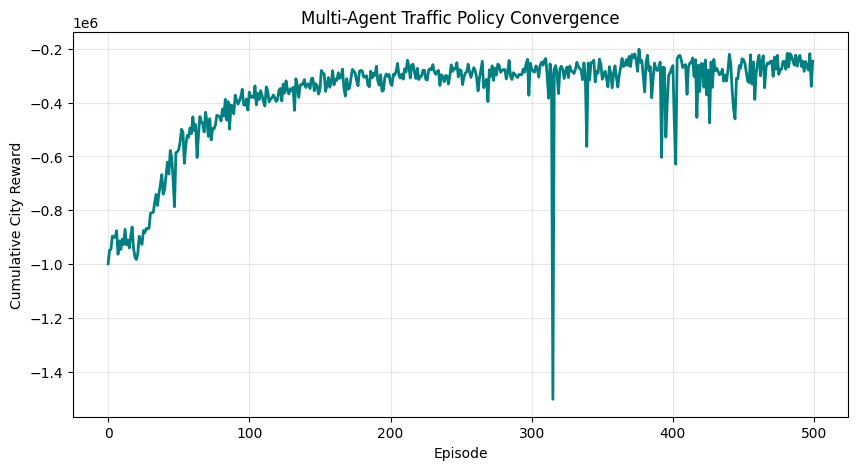

In [6]:
# CELL 6: Configuration and Execution
config_parameters = {
    'episodes': 500,
    'max_steps': 1000,
    'state_dim': 72,
    'action_dim': 9,
    'buffer_limit': 15000, # Per agent, total buffer is 15000 * num_agents
    'batch_sz': 128,
    'update_freq': 4,
    'sync_freq': 8,
    'learning_rate': 1e-4,
    'gamma': 0.99, # Updated from 0.8 to better handle delayed traffic rewards
    'initial_eps': 1.0,
    'min_eps': 0.05,
    'grad_clip': 1.0,
    'save_interval': 250
}

# Run the pipeline
# NOTE: Ensure "../configs/Intersections_4/sample_config.json" exists in your directory
training_history = execute_simulation_run("../configs/Intersections_4/sample_config.json", config_parameters)

# Plotting the Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(training_history, color='teal', linewidth=2)
plt.title("Multi-Agent Traffic Policy Convergence")
plt.xlabel("Episode")
plt.ylabel("Cumulative City Reward")
plt.grid(True, alpha=0.3)
plt.show()